# Исследование корреляции активов с ценой на золото
Теоритически с ценой на золото могут коррелировать следующие типы активов:
1. Другие драгоценные металлы: серебро (SI=F), платина, палладий.
2. Сырьевые товары: Нефть, медь.
3. Валюты: доллар, юань, японская енна, рубль?
4. Золотые фонды (ETF): GLD, IAU, SGOL.
5. Криптовалюты: BTC-USD
6. Цена пшеницы?
7. ОБратная корреляция с ценой на индекс s&p 500? 
---
В теории инвесторы рассматривают золото как защитный актив (защита от инфляции, мировой нестабильности) в условиях повышения цен на энергорессурсы экономики государств, зависящих от поставок энергорессусров (нефть, газ, уголь, медь и т.п.) - повышают ключевые ставки, вследствии увеличения цена производства: Цены растут -> растёт инфляция -> растёт ключевая ставка -> снидается деловая активность -> уменьшается количество рабочих мест -> люди перестают верить в государственные институ -> цена на золото (как актив, который не регулируется финансовыми институтами) должна расти.
**Итог:** теоритически должны иметь отрицательную корреляцию с ценой мировых валют, положительную корреляцию с ценной на сырьевые рессурсы, скорре всего положительную корреляцию с ценой на криптовалюты.  

## Load Data

In [38]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')


tickers = ['GC=F', 'SI=F', 'GLD', 'DX-Y.NYB', 'CL=F', 'DTC-USD', 'HG=F', 'PA=F', 'KE=F', '^GSPC']
data = yf.download(tickers, start='2023-01-01', end='2026-03-10', interval='1d')
close_prices = data['Close'].pct_change().dropna()
close_prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,CL=F,DTC-USD,DX-Y.NYB,GC=F,GLD,HG=F,KE=F,PA=F,SI=F,^GSPC
Date,,,,,,,,,,
2023-01-04,-0.053165,0.011976,-0.002583,0.007121,0.009412,-0.007037,-0.032787,0.061632,-0.011098,0.007539
2023-01-05,0.011395,-0.005917,0.007578,-0.009715,-0.012451,0.020992,-0.001189,-0.035794,-0.022445,-0.011646
2023-01-06,0.001357,0.011905,-0.011043,0.016023,0.018707,0.023703,-0.009229,0.042923,0.024250,0.022841
2023-01-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-01-08,0.000000,0.005882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [39]:
close_prices.describe()

Ticker,CL=F,DTC-USD,DX-Y.NYB,GC=F,GLD,HG=F,KE=F,PA=F,SI=F,^GSPC
count,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,0.000401,0.001658,-0.000048,0.001136,0.001134,0.000595,-0.000239,0.000333,0.001617,0.000645
std,0.018999,0.017528,0.003865,0.010868,0.010860,0.016404,0.016687,0.026303,0.023701,0.008624
min,-0.085680,-0.085672,-0.019728,-0.113662,-0.102742,-0.222531,-0.080298,-0.169497,-0.313468,-0.059750
25%,-0.008979,0.000000,-0.001917,-0.002954,-0.003189,-0.005910,-0.010035,-0.014463,-0.006352,-0.002636
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.011008,0.000000,0.002039,0.006539,0.006012,0.008120,0.007641,0.013165,0.009807,0.004887
max,0.122084,0.100000,0.016148,0.060833,0.063587,0.132511,0.073582,0.158624,0.140253,0.095154


In [40]:
close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 946 entries, 2023-01-04 to 2026-03-09
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CL=F      946 non-null    float64
 1   DTC-USD   946 non-null    float64
 2   DX-Y.NYB  946 non-null    float64
 3   GC=F      946 non-null    float64
 4   GLD       946 non-null    float64
 5   HG=F      946 non-null    float64
 6   KE=F      946 non-null    float64
 7   PA=F      946 non-null    float64
 8   SI=F      946 non-null    float64
 9   ^GSPC     946 non-null    float64
dtypes: float64(10)
memory usage: 81.3 KB


In [41]:
correlation_matrix = close_prices.corr(method='pearson')
gold_correlation = correlation_matrix['GC=F'].sort_values(ascending=False)
print(gold_correlation)

Ticker
GC=F        1.000000
GLD         0.934586
SI=F        0.752917
PA=F        0.460856
HG=F        0.368591
CL=F        0.122017
KE=F        0.058625
^GSPC       0.055324
DTC-USD     0.030586
DX-Y.NYB   -0.397721
Name: GC=F, dtype: float64


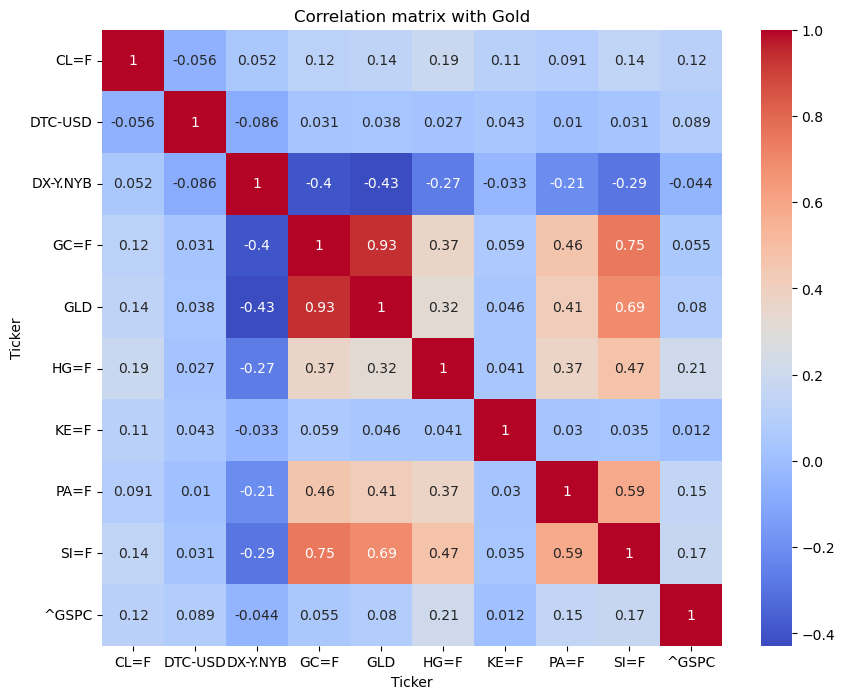

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix with Gold')
plt.show()

**Итого:** самая высокая корреляция с золотым фондом (очевидно), дальше следует цена серебра (SI=F), паладий (PA=F), медь (HG=F), подтвердтлась отрицательная зависимость с ценой на доллар. Цена золота не зависит никак от цены биткоина, нефти, индекса s & p 500 (слабай зависимость). 

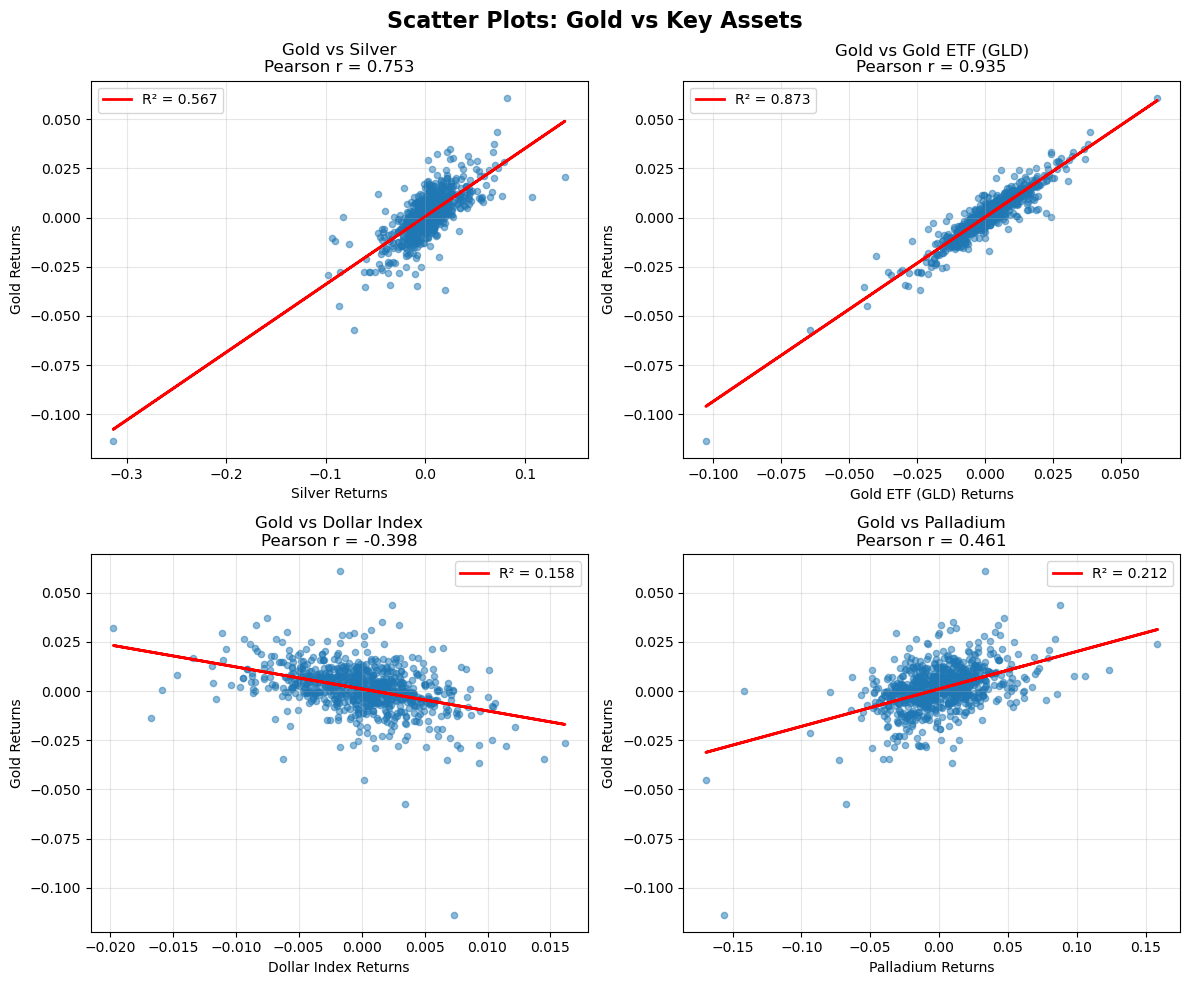

In [43]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

assets_to_plot = ['SI=F', 'GLD', 'DX-Y.NYB', 'PA=F']
titles = ['Silver', 'Gold ETF (GLD)', 'Dollar Index', 'Palladium']

for i, (asset, title) in enumerate(zip(assets_to_plot, titles)):
    x = close_prices[asset]
    y = close_prices['GC=F']
    
    # Удалите пропуски
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    
    # Рассчитайте линию регрессии
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    line = slope * x_clean + intercept
    
    axes[i].scatter(x_clean, y_clean, alpha=0.5, s=20)
    axes[i].plot(x_clean, line, 'r-', linewidth=2, label=f'R² = {r_value**2:.3f}')
    axes[i].set_xlabel(f'{title} Returns')
    axes[i].set_ylabel('Gold Returns')
    axes[i].set_title(f'Gold vs {title}\nPearson r = {correlation_matrix.loc["GC=F", asset]:.3f}')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Scatter Plots: Gold vs Key Assets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()